# Importing Packages & Files

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from sklearn.mixture import GaussianMixture

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

In [ ]:
df_scaled = pd.read_csv('../data/processed/bank_churners_question_1_scaled.csv')
df_encoded = pd.read_csv('../data/processed/bank_churners_question_1_encoded.csv')

In [ ]:
kmeans_data  = df_encoded.copy()
kmeans_data_clustered = df_encoded.copy()
gmm_data  = df_encoded.copy()
gmm_data_clustered = df_encoded.copy()
hc_data  = df_encoded.copy()
hc_data_clustered = df_encoded.copy()
dbscan_data  = df_encoded.copy()
dbscan_data_clustered = df_encoded.copy()
df_cleaned = df_encoded.copy()

# Hierarchical Clustering

## Modelling

### Plotting Dendrogram

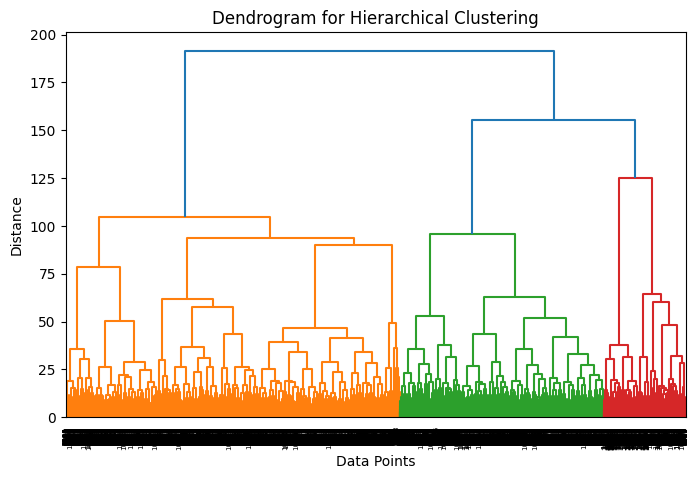

In [ ]:
# Create the linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 5))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Running Hierarchical Clustering

In [ ]:
# We will use 5 clusters as suggested by the Dendrogram
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
hc_clustered = hc.fit_predict(df_scaled)

In [ ]:
hc_segmented = hc_clustered.copy()

hc_data_clustered['Cluster'] = hc_segmented

## Plotting Clusters Distribution

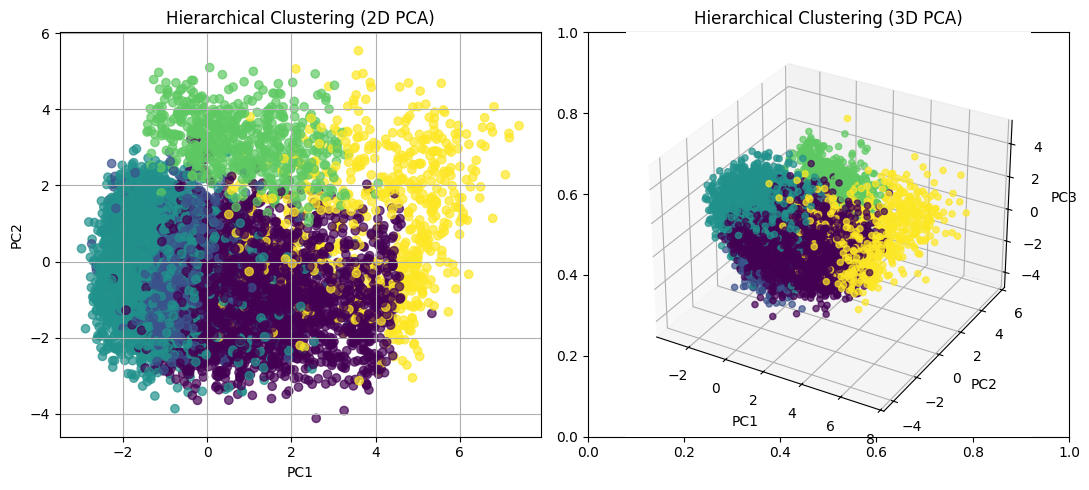

In [ ]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=hc_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Hierarchical Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=hc_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("Hierarchical Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [ ]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(hc_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
0    3333
1    1507
2    3956
3     564
4     767
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

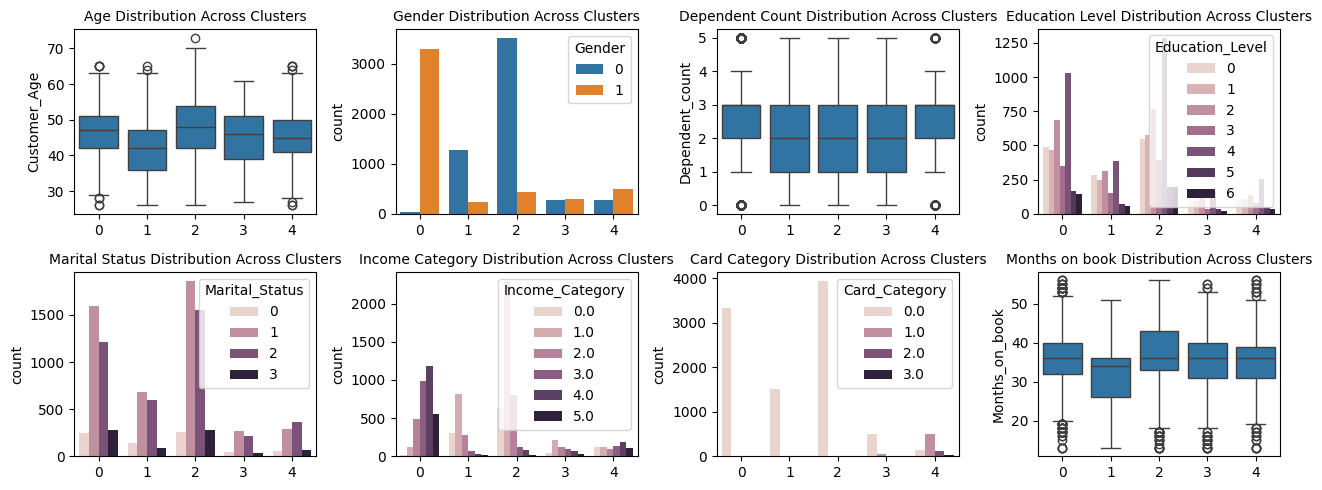

In [ ]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
0,46.535854,0.990699,2.572157,2.615062,1.458746,3.461746,0.001500,36.193819
1,41.383543,0.155275,2.261447,2.370272,1.412077,1.173192,0.000000,31.319841
2,48.370071,0.112487,2.172396,2.672649,1.467897,1.185288,0.001769,37.749747
3,45.102837,0.508865,2.195035,2.464539,1.452128,2.012411,0.097518,34.976950
4,45.481095,0.653194,2.538462,2.736636,1.569752,2.597132,1.016949,35.135593


### Transactional Data

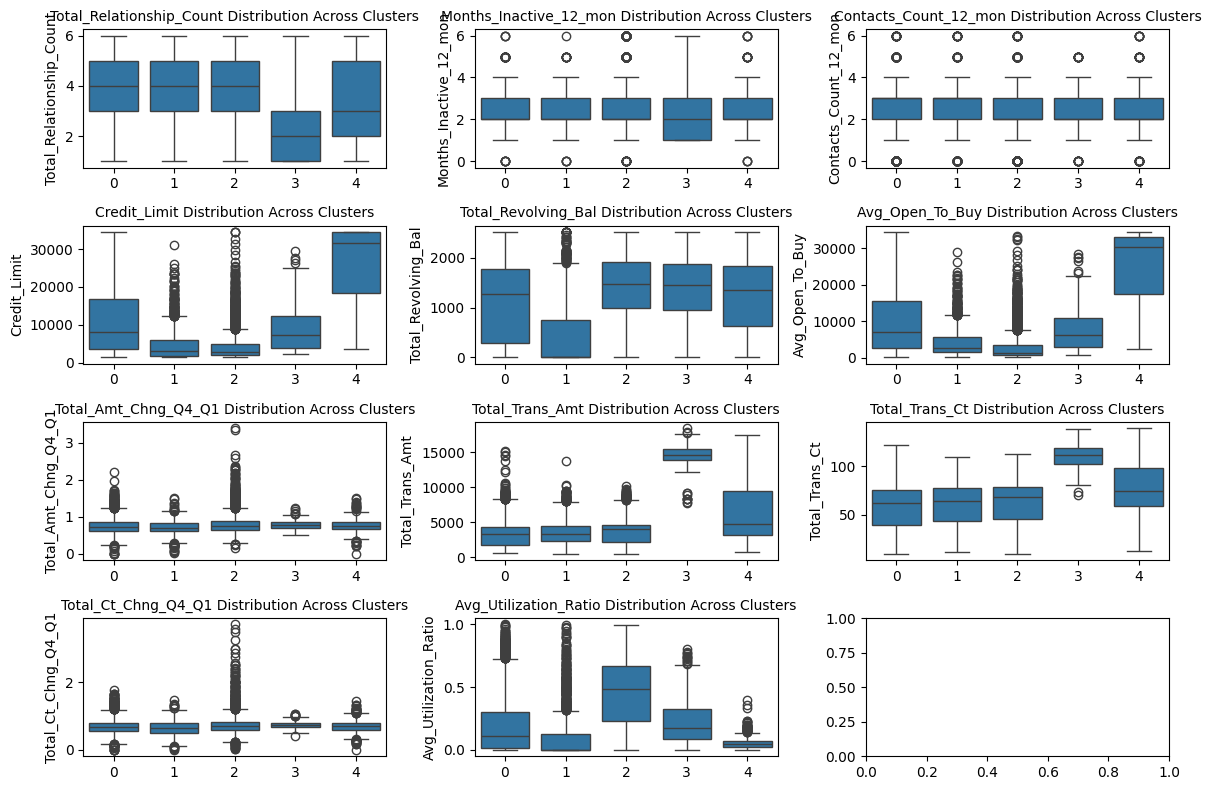

In [ ]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 8))

sns.boxplot(x=hc_clustered, y=hc_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
0,3.942694,11443.730123,10279.645215,3435.159016,58.661566,0.204265
1,3.885202,4546.830325,4148.862177,3523.972794,61.079628,0.098979
2,3.981547,4237.820854,2820.638094,3604.635996,62.870829,0.452448
3,2.312057,8867.157801,7509.959220,14631.301418,109.897163,0.220819
4,3.336375,26930.734029,25725.584094,6946.774446,76.348110,0.051425


## Cluster Analysis

*   **Cluster 0: Mid-High Income Males with Dependents, Strong Banking Relationship**
      - Likely financially stable men managing family expenses with good banking engagement and responsible credit use.
*   **Cluster 1: Young, Low-Income Females with Shortest Tenure & Low Credit**
      - Newer bank customers with limited financial history, lower credit access, and cautious spending.
*   **Cluster 2: Older, Low-Income Females with Strong Banking Relationship & High Utilisation**
      - Long-term customers with lower incomes, relying heavily on credit, possibly facing financial constraints.
*  **Cluster 3: Mid-Income Graduates with High Spending & Transactions**
      - Likely financially independent individuals who spend actively but don’t engage deeply with the bank.
*   **Cluster 4: Educated, Single Individuals with High Credit & Low Utilisation**
      - Financially stable, independent, and responsible spenders who manage credit well.




# K-means Clustering

## Modelling

In [ ]:
def try_different_clusters(K, data):

    cluster_values = list(range(1, K+1))
    inertias=[]

    for c in cluster_values:
        model = KMeans(n_clusters = c,init='k-means++',max_iter=400,random_state=3101)
        model.fit(data)
        inertias.append(model.inertia_)

    return inertias

In [ ]:
# Find output for k values between 1 to 15
outputs = try_different_clusters(15, df_scaled)
distances = pd.DataFrame({"clusters": list(range(1, 16)),"sum of squared distances": outputs})

# Finding optimal number of clusters k
figure = go.Figure()
figure.add_trace(go.Scatter(x=distances["clusters"], y=distances["sum of squared distances"]))

figure.update_layout(xaxis = dict(tick0 = 1,dtick = 1,tickmode = 'linear'),
                  xaxis_title="Number of clusters",
                  yaxis_title="Sum of squared distances",
                  title_text="Finding optimal number of clusters using elbow method")
figure.show()

In [ ]:
# Based on the Elbow Method, we will use 6 clusters
kmeans_model_new = KMeans(n_clusters = 6,init='k-means++',max_iter=400,random_state=3101)
kmeans_clustered = kmeans_model_new.fit_predict(df_scaled)

In [ ]:
kmeans_segmented = kmeans_clustered.copy()

# Add cluster labels
kmeans_data_clustered['Cluster'] = kmeans_segmented  # Add cluster labels to the dataframe

## Plotting Clusters Distribution

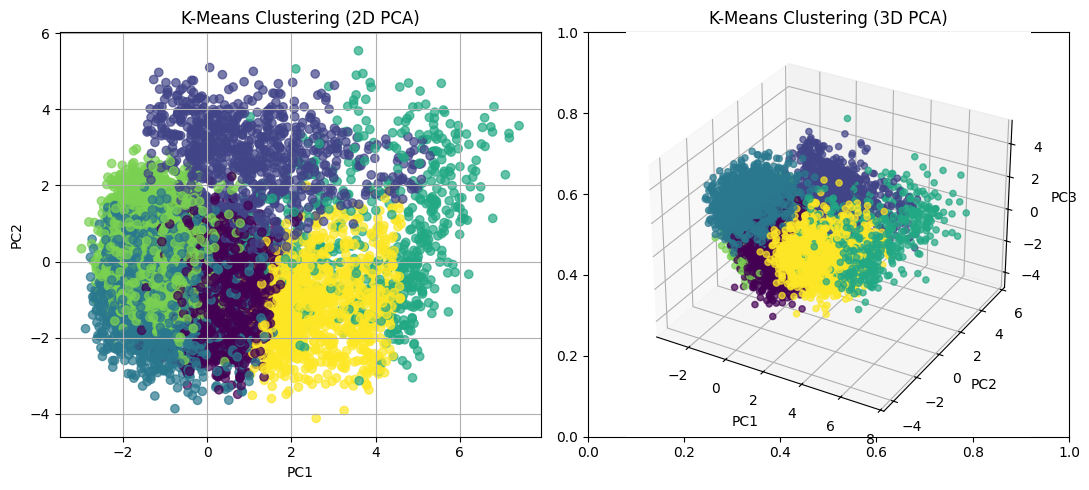

In [ ]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=kmeans_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("K-Means Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=kmeans_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("K-Means Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [ ]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(kmeans_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
0    2351
1     834
2    1853
3     572
4    3409
5    1108
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

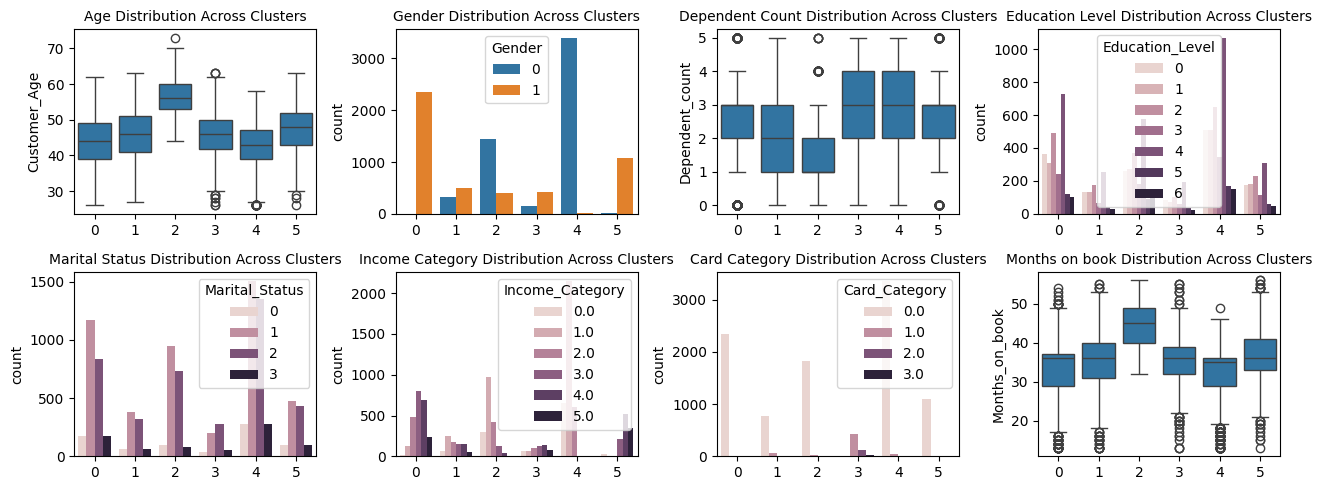

In [ ]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=kmeans_clustered, y=kmeans_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=kmeans_clustered, hue=kmeans_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=kmeans_clustered, y=kmeans_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=kmeans_clustered, hue=kmeans_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=kmeans_clustered, hue=kmeans_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=kmeans_clustered, hue=kmeans_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=kmeans_clustered, hue=kmeans_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=kmeans_clustered, y=kmeans_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
kmeans_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
0,43.725649,1.000000,2.481072,2.605700,1.431731,3.153552,0.000425,33.645257
1,45.386091,0.603118,2.304556,2.497602,1.460432,2.308153,0.071942,35.171463
2,56.206152,0.216945,1.305990,2.665947,1.432812,1.282785,0.009174,44.755532
3,45.770979,0.722028,2.582168,2.723776,1.597902,2.798951,1.272727,35.548951
4,42.765327,0.004693,2.731300,2.603696,1.473159,0.986800,0.011734,32.637137
5,47.268953,0.978339,2.524368,2.497292,1.484657,4.008123,0.000903,36.902527


### Transactional Data

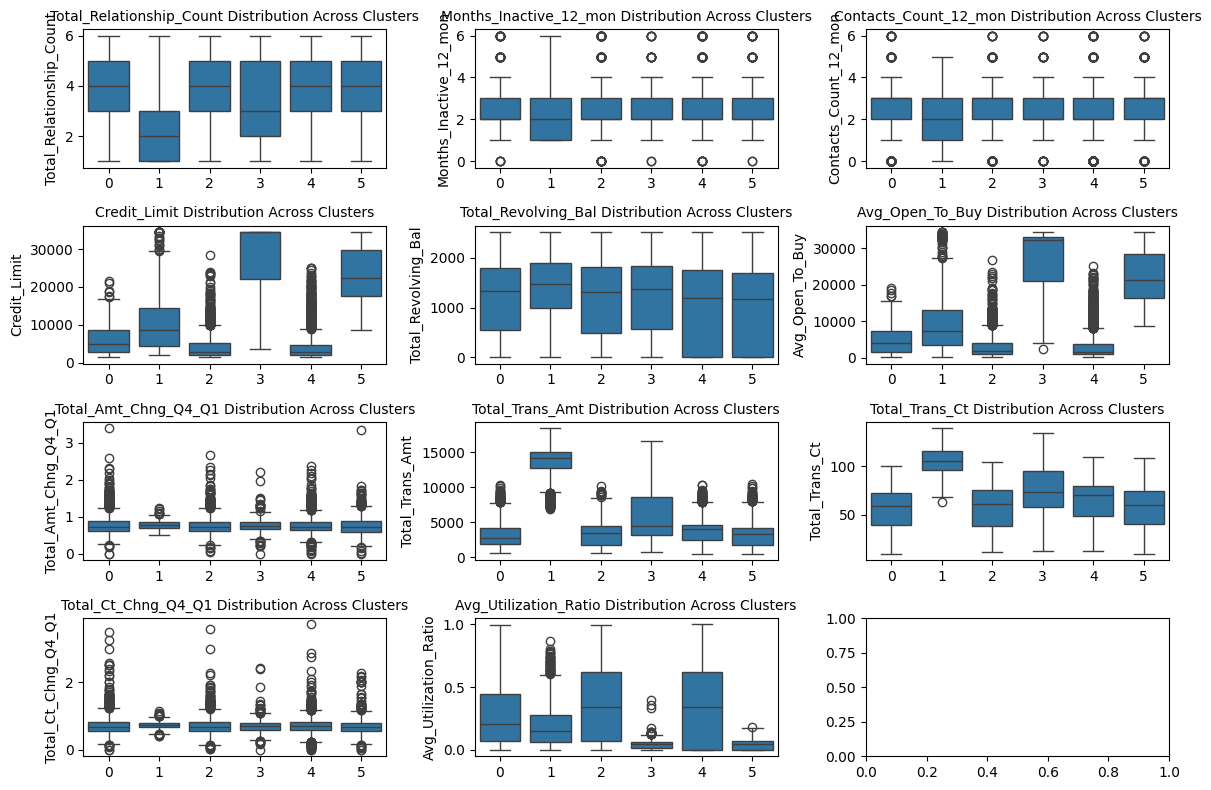

In [ ]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 9))

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=kmeans_clustered, y=kmeans_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
kmeans_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
0,4.153126,5961.760953,4772.490430,3101.500638,56.592939,0.272681
1,2.155875,10899.206235,9533.454436,13195.083933,105.786571,0.199760
2,4.008635,4260.335888,3076.029897,3251.896384,57.748516,0.364882
3,3.330420,28753.879371,27552.062937,6508.800699,74.937063,0.045636
4,3.915518,4104.432004,2993.780199,3752.264594,65.031388,0.358322
5,3.941336,23444.157942,22385.822202,3396.738267,57.747292,0.047314


## Cluster Analysis

*   **Cluster 0: Mid-High Income Married Men, Moderate Credit Utilisation & High Engagement**
      - Financially stable individuals who actively engage with the bank and manage their credit responsibly.
*   **Cluster 1: Mid-Income, Frequent Spenders with Low Engagement**
      - Active credit users who spend frequently but may not have strong ties with the bank.
*   **Cluster 2: Older, Low-Income Women, Strong Banking Relationship & High Credit Utilisation**
      - Likely financially constrained individuals who rely on credit to manage expenses.
*   **Cluster 3: Single, College-Educated Males with High Available Credit & Low Utilisation**
      - Responsible spenders with good financial habits and minimal reliance on credit.
*   **Cluster 4: Young, Low-Income Women with High Debt Usage**
      - Likely financially vulnerable individuals who rely heavily on credit, possibly accumulating debt.
*   **Cluster 5: High-Income Males with Strong Credit Stability**
      - Financially stable individuals with significant credit access but minimal reliance on debt.


# Gaussian Mixture Model (GMM)

## Modelling

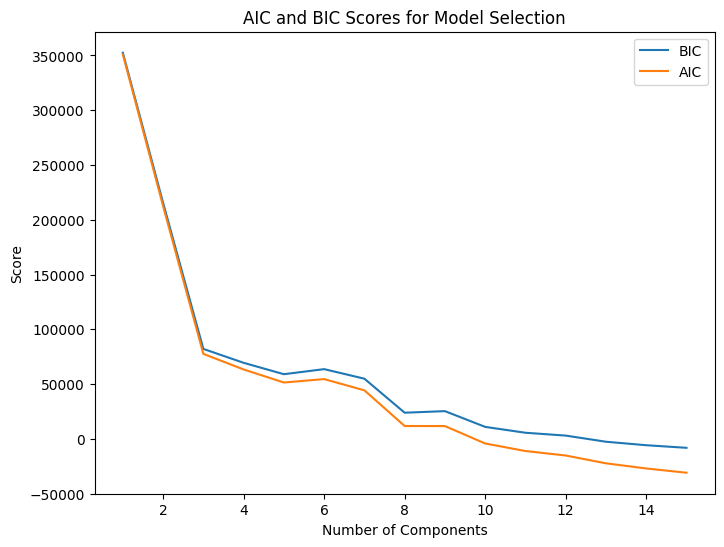

In [ ]:
# Prepare range of components
n_components = np.arange(1, 16)

# Create GMM Models
models = [GaussianMixture(n_components=n, random_state=3101).fit(df_scaled) for n in n_components]

# Plot AIC and BIC values
plt.figure(figsize=(8, 6))
plt.plot(n_components, [m.bic(df_scaled) for m in models], label='BIC')
plt.plot(n_components, [m.aic(df_scaled) for m in models], label='AIC')
plt.legend()
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('AIC and BIC Scores for Model Selection')
plt.show()

In [ ]:
# Create GM Models
# We will use 8 components as the AIC and BIC scores even out after that
gmm_model = GaussianMixture(n_components = 8, random_state=3101).fit(df_scaled)
gmm_clustered = pd.Series(gmm_model.predict(df_scaled))

In [ ]:
print(f'Converged: {gmm_model.converged_}')

Converged: True


In [ ]:
gmm_segmented = gmm_clustered.copy()

gmm_data_clustered['Cluster'] = gmm_segmented

## Plotting Clusters Distribution

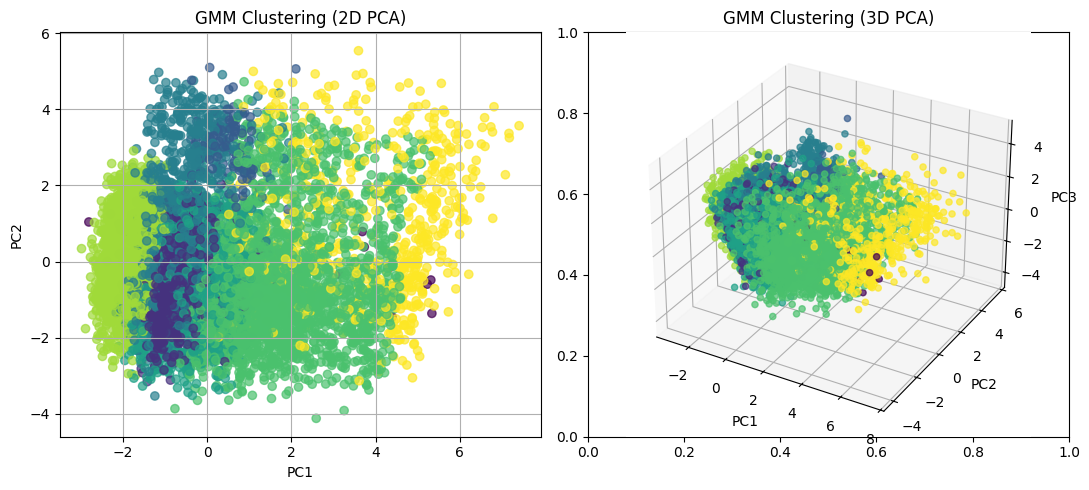

In [ ]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=gmm_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("GMM Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=gmm_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("GMM Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [ ]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(gmm_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
0      54
1    1263
2      96
3    1587
4    1718
5    2499
6    2228
7     682
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

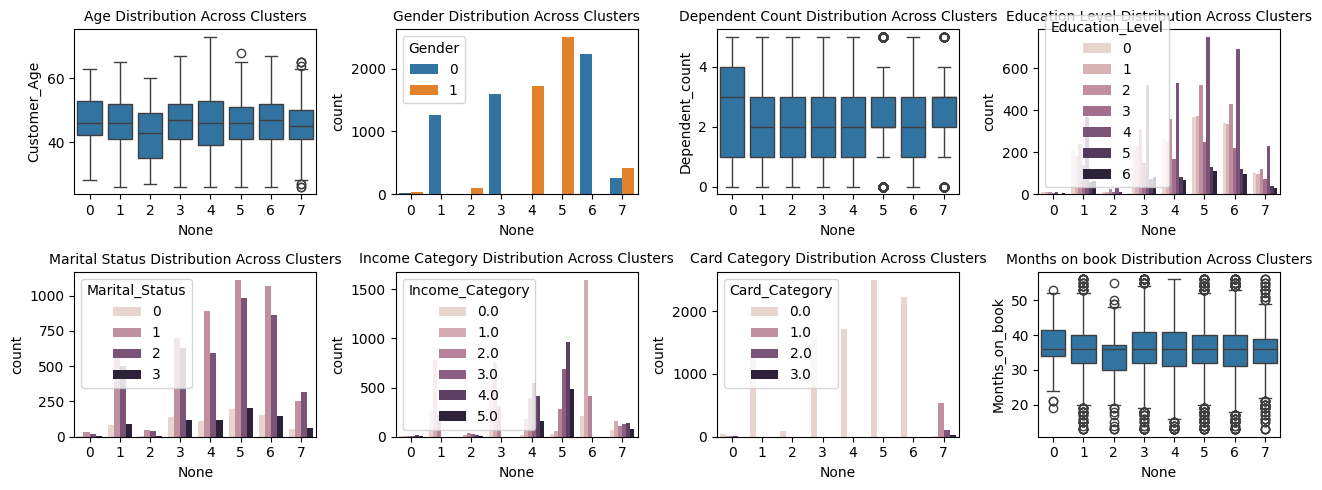

In [ ]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=gmm_clustered, y=gmm_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=gmm_clustered, hue=gmm_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=gmm_clustered, y=gmm_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=gmm_clustered, hue=gmm_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=gmm_clustered, hue=gmm_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=gmm_clustered, hue=gmm_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=gmm_clustered, hue=gmm_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=gmm_clustered, y=gmm_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
gmm_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
0,46.574074,0.629630,2.481481,2.481481,1.425926,2.407407,0.351852,36.870370
1,46.373713,0.000000,2.334125,2.547902,1.470309,0.969121,0.000000,36.124307
2,42.750000,0.989583,2.135417,2.822917,1.406250,2.614583,0.062500,33.343750
3,46.666037,0.000000,2.301827,2.672338,1.460618,0.880907,0.000000,36.218652
4,46.272992,1.000000,2.213620,2.563446,1.424913,2.938300,0.000000,35.935972
5,46.274110,1.000000,2.421769,2.586234,1.475790,3.579032,0.000000,35.946379
6,46.512567,0.000000,2.362657,2.594255,1.447038,1.090664,0.000000,35.841562
7,45.643695,0.620235,2.494135,2.696481,1.573314,2.488270,1.205279,35.378299


### Transactional Data

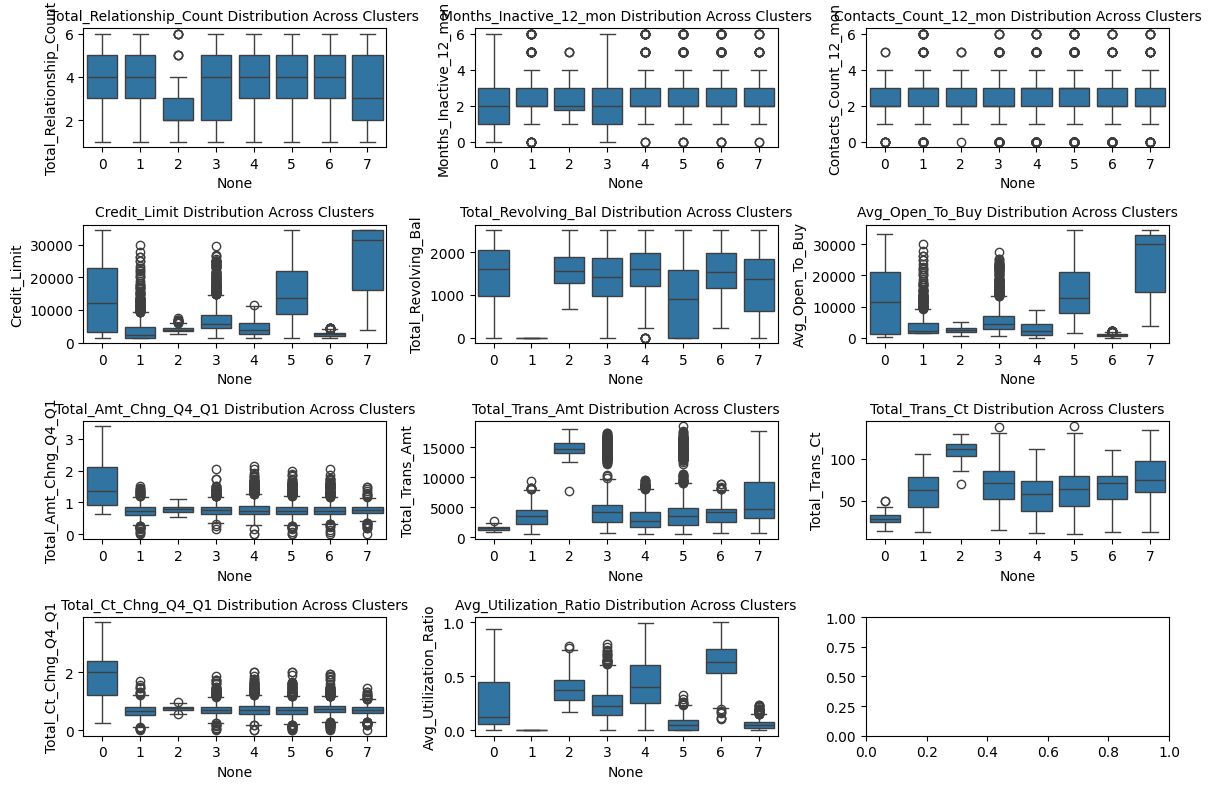

In [ ]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 8))

sns.boxplot(x=gmm_clustered, y=gmm_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=gmm_clustered, y=gmm_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
gmm_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
0,4.037037,14521.320370,13020.301852,1518.814815,28.500000,0.246074
1,3.793349,3830.720903,3830.720903,3408.631037,60.129850,0.000000
2,2.520833,4292.583333,2684.697917,14831.583333,110.520833,0.390479
3,3.645243,7150.196471,5719.531065,5430.512917,70.368620,0.245060
4,4.144354,4462.802212,2863.621769,3132.401048,57.002328,0.437587
5,3.725090,15657.555702,14774.167947,4667.775110,63.774310,0.055454
6,3.986086,2460.174417,892.327917,3768.725763,66.082585,0.635868
7,3.319648,26037.241935,24832.256598,6932.629032,77.011730,0.054391


## Cluster Analysis

*   **Cluster 0: Established, Low-Middle Income & Low Transaction Activity**
      - Long-term customers with moderate income who hold a strong banking relationship but engage in minimal transactions.
*   **Cluster 1: Low-Income Females, Low Credit & No Utilisation**
      - Financially cautious or underserved female customers with limited credit and no active usage.
*   **Cluster 2: Young, Educated Males, High Transactions & Spending**
      - New customers, actively using their credit cards, spending a lot, but may not have deep ties with the bank yet.
*  **Cluster 3: Married, Educated Males, Moderate Spending**
      - Middle-class, financially stable individuals using their credit responsibly.
*   **Cluster 4: Low-Income Females, Moderate Credit & Utilisation**
      - Financially constrained but maintaining a banking relationship with controlled credit use.
*  **Cluster 5: Middle-High Income Males, High Credit & Low Utilisation**
      - Higher-income males with access to large credit but using it conservatively.
*   **Cluster 6: Graduates with Dependents, High Utilisation & Low Credit**
      - Likely young families with financial commitments, stretching their limited credit.
*   **Cluster 7: Affluent Customers, Very High Credit, Low Utilisation**
      - Well-off customers who maintain financial discipline and high creditworthiness.




# Density-Based Spatial Clustering of Applications with Noise (DBSCAN)


## Modelling

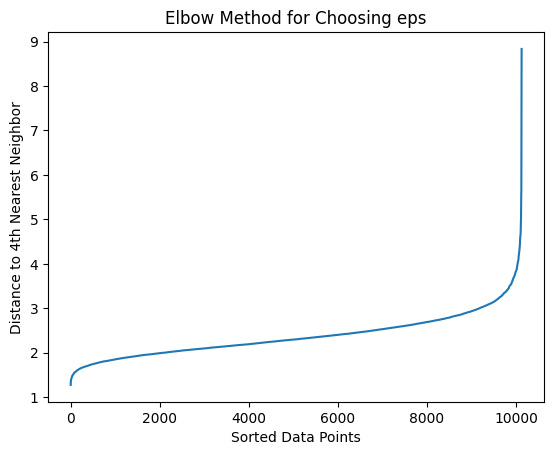

In [ ]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Sort and plot the distances to find the "elbow"
distances = np.sort(distances[:, 3], axis=0)  # 3rd index = 4th neighbor
plt.plot(distances)
plt.xlabel("Sorted Data Points")
plt.ylabel("Distance to 4th Nearest Neighbor")
plt.title("Elbow Method for Choosing eps")
plt.show()

In [ ]:
# Apply DBSCAN
# Using the Elbow Method, we decided to use eps = 3.7
dbscan = DBSCAN(eps=3.7, min_samples=40, metric='euclidean')
dbscan_clustered = dbscan.fit_predict(df_scaled)

In [ ]:
dbscan_segmented = dbscan_clustered.copy()

dbscan_data_clustered['Cluster'] = dbscan_segmented

## Plotting Clusters Distribution

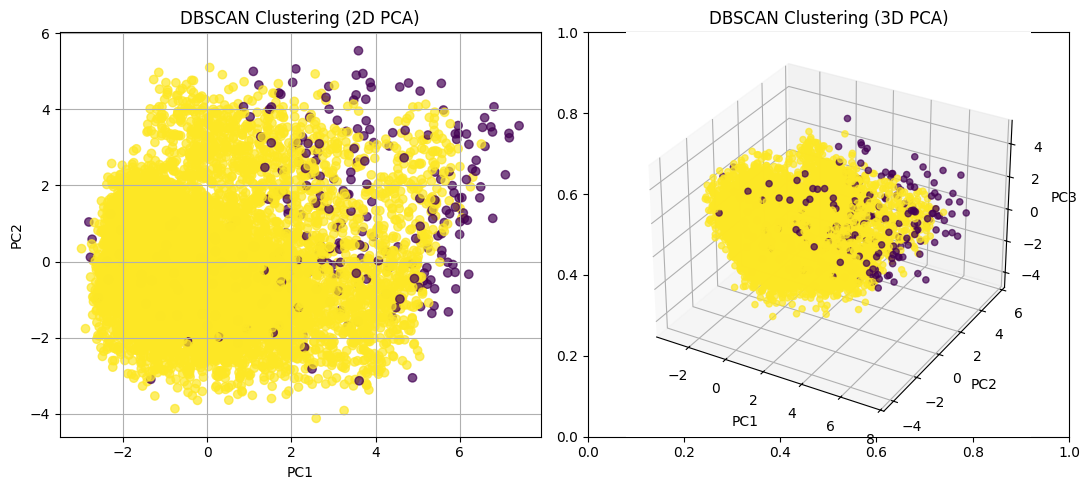

In [ ]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=dbscan_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("DBSCAN Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=dbscan_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("DBSCAN Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [ ]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(dbscan_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
-1     275
 0    9852
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

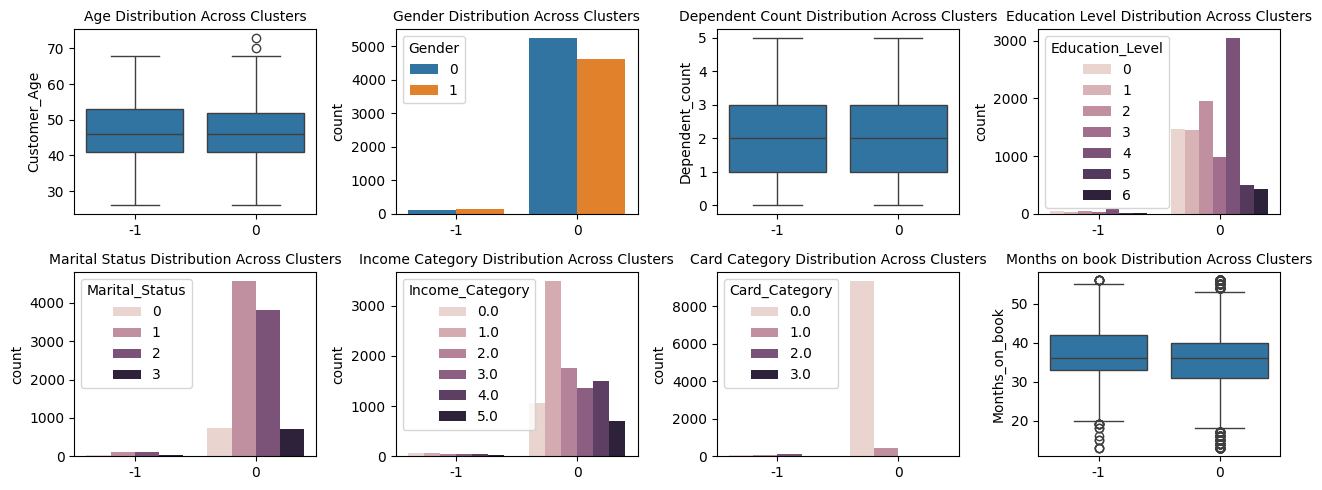

In [ ]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=dbscan_clustered, y=dbscan_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=dbscan_clustered, hue=dbscan_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=dbscan_clustered, y=dbscan_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=dbscan_clustered, hue=dbscan_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=dbscan_clustered, hue=dbscan_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=dbscan_clustered, hue=dbscan_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=dbscan_clustered, hue=dbscan_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=dbscan_clustered, y=dbscan_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
dbscan_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
-1,46.538182,0.560000,2.149091,2.541818,1.589091,2.080000,1.24000,36.760000
0,46.320037,0.468433,2.351705,2.603634,1.459907,2.085871,0.05136,35.905197


### Transactional Data

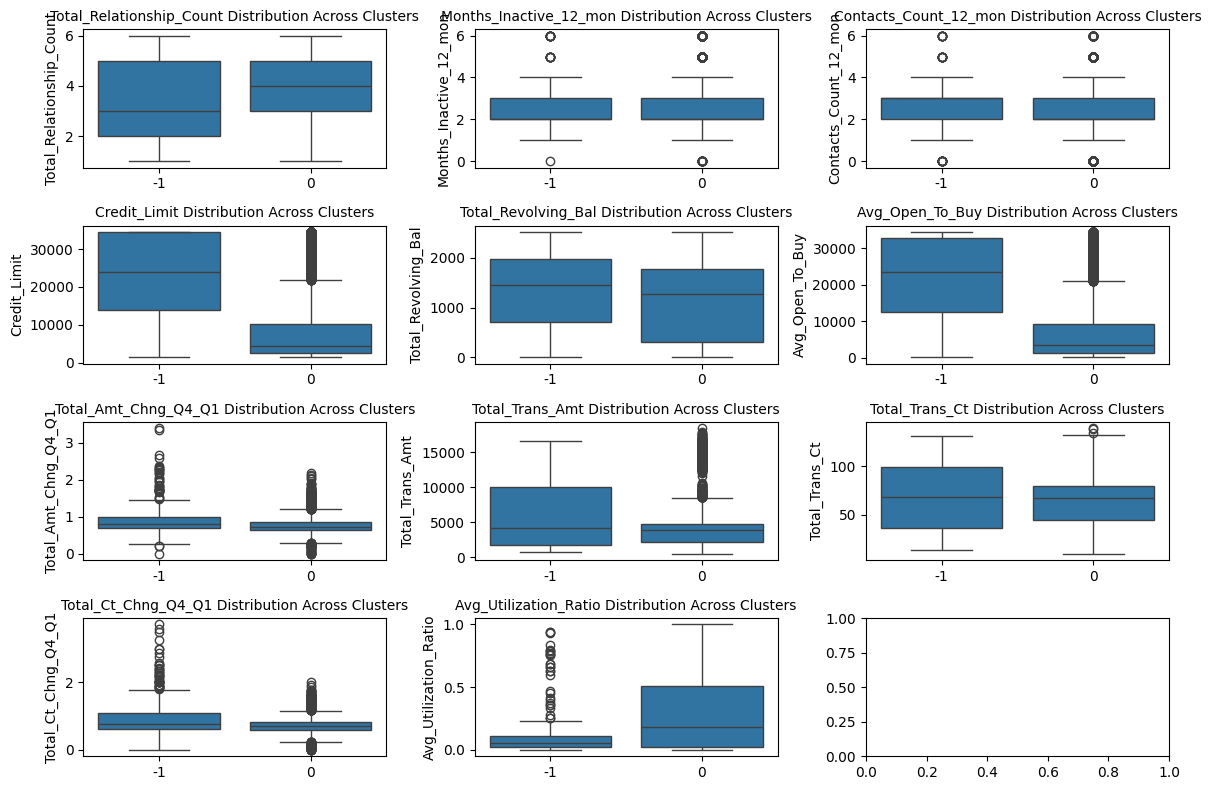

In [ ]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 8))

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=dbscan_clustered, y=dbscan_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
dbscan_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
-1,3.247273,23003.763636,21686.283636,6452.290909,68.774545,0.116291
0,3.828360,8230.791728,7072.294874,4346.914535,64.749391,0.279321


## Cluster Analysis


*   **Cluster 0: Affluent Customers with Silver Cards & High Credit Access**
      - Likely wealthier, financially stable customers who have strong banking relationships, access to significant credit, and maintain disciplined spending.
*   **Cluster 1: General Population with Blue Cards & Moderate Credit Usage**
      - Likely mid-income or lower-income customers with moderate credit access, more reliance on available credit, and a tendency to use a higher proportion of it.




# Validation

Since clustering is an unsupervised learning method, there is no 'ground truth' to directly compare the results against. However, we can utilise validation metrics and domain knowledge to assess the compactness of clusters and their separation from one another. This allows us to evaluate the overall quality of the clustering results.

## Validation Metrics

### Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. It is based on the average distance between points within the same cluster and between points in different clusters.

It ranges from -1 (wrong assignments) to 1 (well-separated and compact clusters). Values close to 0 imply overlapping clusters (unclear separation).

In [ ]:
sil_score_kmeans = silhouette_score(kmeans_data, kmeans_clustered)
print(f'Silhouette Score: {sil_score_kmeans:.4f}')

Silhouette Score: -0.0135


In [ ]:
sil_score_gmm = silhouette_score(gmm_data, gmm_clustered)
print(f'Silhouette Score: {sil_score_gmm:.4f}')

Silhouette Score: -0.0601


In [ ]:
sil_score_hc = silhouette_score(hc_data, hc_clustered)
print(f'Silhouette Score: {sil_score_hc:.4f}')

Silhouette Score: -0.0473


In [ ]:
sil_score_dbscan = silhouette_score(dbscan_data, dbscan_clustered)
print(f'Silhouette Score: {sil_score_dbscan:.4f}')

Silhouette Score: 0.4531


- Most scores are close to 0 (-0.0135, -0.0601, -0.0473), which means unclear separation between clusters.
- A negative score suggests that some points may be closer to another cluster than their assigned one.
- The highest score (0.4531) occurs when you have two clusters, meaning the data naturally forms a general group and an outlier group (affluent population).
- This suggests that beyond the affluent group, it’s difficult to segment the general population further in a meaningful way.

### Calinski-Harabasz (CH) Score

The Calinski-Harabasz Index measures the ratio of between-cluster dispersion to within-cluster dispersion.

Higher values indicate better-defined clusters.

In [ ]:
ch_index_kmeans = calinski_harabasz_score(kmeans_data, kmeans_clustered)
print(f"Calinski-Harabasz Score: {ch_index_kmeans}")

Calinski-Harabasz Score: 4999.65304289861


In [ ]:
ch_index_gmm = calinski_harabasz_score(gmm_data, gmm_clustered)
print(f"Calinski-Harabasz Score: {ch_index_gmm}")

Calinski-Harabasz Score: 1826.1052271625517


In [ ]:
ch_index_hc = calinski_harabasz_score(hc_data, hc_clustered)
print(f"Calinski-Harabasz Score: {ch_index_hc}")

Calinski-Harabasz Score: 2225.110790161414


In [ ]:
ch_index_dbscan = calinski_harabasz_score(dbscan_data, dbscan_clustered)
print(f"Calinski-Harabasz Score: {ch_index_dbscan}")

Calinski-Harabasz Score: 703.3523763783138


- The highest score (4999.65) is achieved with K-Means (6 clusters), indicating the best-defined and most separated clusters.
- The score drops significantly with GMM (8 clusters) to 1826.10, suggesting that increasing the number of clusters leads to overlap and weaker separation.
- Hierarchical Clustering (5 clusters) gives a CH score of 2225.11, which is better than GMM but still weaker than K-Means, indicating that while some structure exists, the separation is not as strong.
- DBSCAN (2 clusters) results in the lowest CH score (703.35), reinforcing that it mainly detects one large general group and an outlier group, rather than well-separated clusters.

## Domain Knowledge

Other than using Validation Metrics, we can also utilise Domain Knowledge to evaluate the quality of the clusters. While validation metrics provide a quantitative measure of compactness, separation, and structure, they do not always capture the contextual relevance of the clusters in real-world terms.

### Previous Clusters

For K-means Clustering:
*   **KM C0: Mid-High Income Married Men, Moderate Credit Utilisation & High Engagement**
      - Financially stable individuals who actively engage with the bank and manage their credit responsibly.
*   **KM C1: Mid-Income, Frequent Spenders with Low Engagement**
      - Active credit users who spend frequently but may not have strong ties with the bank.
*   **KM C2: Older, Low-Income Women, Strong Banking Relationship & High Credit Utilisation**
      - Likely financially constrained individuals who rely on credit to manage expenses.
*   **KM C3: Single, College-Educated Males with High Available Credit & Low Utilisation**
      - Responsible spenders with good financial habits and minimal reliance on credit.
*   **KM C4: Young, Low-Income Women with High Debt Usage**
      - Likely financially vulnerable individuals who rely heavily on credit, possibly accumulating debt.
*   **KM C5: High-Income Males with Strong Credit Stability**
      - Financially stable individuals with significant credit access but minimal reliance on debt.

For GMM:
*   **GMM C0: Established, Low-Middle Income & Low Transaction Activity**
      - Long-term customers with moderate income who hold a strong banking relationship but engage in minimal transactions.
*   **GMM C1: Low-Income Females, Low Credit & No Utilisation**
      - Financially cautious or underserved female customers with limited credit and no active usage.
*   **GMM C2: Young, Educated Males, High Transactions & Spending**
      - New customers, actively using their credit cards, spending a lot, but may not have deep ties with the bank yet.
*  **GMM C3: Married, Educated Males, Moderate Spending**
      - Middle-class, financially stable individuals using their credit responsibly.
*   **GMM C4: Low-Income Females, Moderate Credit & Utilisation**
      - Financially constrained but maintaining a banking relationship with controlled credit use.
*  **GMM C5: Middle-High Income Males, High Credit & Low Utilisation**
      - Higher-income males with access to large credit but using it conservatively.
*   **GMM C6: Graduates with Dependents, High Utilisation & Low Credit**
      - Likely young families with financial commitments, stretching their limited credit.
*   **GMM C7: Affluent Customers, Very High Credit, Low Utilisation**
      - Well-off customers who maintain financial discipline and high creditworthiness.

For Hierarchical Clustering:
*   **HC C0: Mid-High Income Males with Dependents, Strong Banking Relationship**
      - Likely financially stable men managing family expenses with good banking engagement and responsible credit use.
*   **HC C1: Young, Low-Income Females with Shortest Tenure & Low Credit**
      - Newer bank customers with limited financial history, lower credit access, and cautious spending.
*   **HC C2: Older, Low-Income Females with Strong Banking Relationship & High Utilisation**
      - Long-term customers with lower incomes, relying heavily on credit, possibly facing financial constraints.
*  **HC C3: Mid-Income Graduates with High Spending & Transactions**
      - Likely financially independent individuals who spend actively but don’t engage deeply with the bank.
*   **HC C4: Educated, Single Individuals with High Credit & Low Utilisation**
      - Financially stable, independent, and responsible spenders who manage credit well.


For DBSCAN:

*   **DBSCAN C0: Affluent Customers with Silver Cards & High Credit Access**
      - Likely wealthier, financially stable customers who have strong banking relationships, access to significant credit, and maintain disciplined spending.
*   **DBSCAN C1: General Population with Blue Cards & Moderate Credit Usage**
      - Likely mid-income or lower-income customers with moderate credit access, more reliance on available credit, and a tendency to use a higher proportion of it.

### Re-grouping Clusters

After analysing the clusters from each model, we found that the majority of the clusters could be grouped together, as similar groupings appeared across different models.

This can be seen as follows (without the inclusion of the clusters from DBSCAN, which tends to produce more general clusters and identify outliers):

*   **Financially Stable/High-Income Individuals:** KM C0, GMM C3, HC C0, GMM C5, KM C5, GMM C7
      - These clusters represent individuals with higher income, strong credit management, and a solid relationship with the bank.

*   **Active Spenders with Low Bank Engagement:** KM C1, GMM C2, HC C3
      - These clusters capture individuals who are actively spending but have a lower level of engagement with the bank. They may be using their credit actively but do not have deep ties with the financial institution.

*   **Financially Constrained, High-Risk Spenders:** KM C2, HC C2, GMM C1, KM C4, GMM C4, HC C1
      - These clusters represent individuals who are financially constrained and are relying heavily on credit, possibly accumulating debt. They may be vulnerable to financial stress due to high credit utilisation or low income.

* **Responsible, Low-Risk Spenders:** KM C3, HC C4
    - These individuals are responsible with their credit, often with high available credit but minimal reliance on it. They are financially stable, independent, and manage their credit responsibly.

* **Family-Oriented, Financially Constrained Group:** GMM C6
    - This group represents individuals with dependents, likely young families who may have limited credit and are utilising it more heavily, which suggests a higher financial risk.

* **Established, Low-Income, Low-Engagement Customers:** GMM C0
    - These individuals are long-term customers with a moderate income but have low transaction activity. They may have a strong banking relationship but aren’t very active with their accounts or credit usage.

The new clusters match the findings from BAI (2012).

For example, our Financially Stable/High-Income Individuals cluster aligns with the Sophisticated Opportunists group found by BAI, who typically have higher incomes and are very satisfied with their banking relationships.

Our Financially Constrained, High-Risk Spenders cluster closely matches the Struggling Techies group due to their lower income and potential financial vulnerability.

The Satisfied Traditionalists group mirrors our Responsible, Low-Risk Spenders cluster, as both include older individuals with average incomes who are financially stable and responsible.

The Marginalized Middles group aligns with our Active Spenders with Low Bank Engagement cluster, as they share high incomes but low engagement with their bank.

Another example would be our Established, Low-Income, Low-Engagement Customers cluster, which closely mirrors the Disengaged Skeptics group due to their low engagement and low income.

As such, the results from these models align with real-world patterns, supporting the validity and relevance of the clusters.

# Conclusion

Therefore, while the validation metrics suggest that the clusters may lack clear separation, the application of domain knowledge reveals that the identified clusters align closely with real-world patterns, confirming their relevance and coherence in reflecting actual consumer behavior.

This demonstrates the inherent challenge of customer segmentation and underscores why finding meaningful clusters is so valuable. By understanding these distinct groups, we can better personalize our marketing strategies and products to cater to the specific needs of each segment, ultimately improving customer engagement and satisfaction.

However, if we had to choose one clustering model, based on the model evaluation, Hierarchical Clustering would be the most suitable choice as it provided the best results in terms of clustering quality.

- Calinski-Harabasz Score: 2225.11 (indicating a strong clustering structure)
- Silhouette Score: -0.0473 (while negative, this reflects a better fit compared to other models)
- This model aligns most closely with expert insights, producing clusters that make sense based on domain knowledge.

Compared to other methods:
- K-Means with 6 clusters achieved higher Silhouette and Calinski-Harabasz scores, indicating that it performed well in terms of cluster cohesion and separation. However, the results were very similar to those from Hierarchical Clustering, and the additional clusters didn't add much value in terms of interpretability.
- GMM with 8 clusters resulted in an overly complex model with a large number of clusters, which may be difficult to interpret meaningfully.
- DBSCAN with 2 clusters produced a very generalised clustering, oversimplifying the segmentation and missing finer distinctions between groups.

Given that Hierarchical Clustering provides comparable results with fewer clusters, it is a more efficient and interpretable choice.

# Citations

BAI. (2012). The New Dynamics of Consumer Banking Relationships. BAI Research Study. https://www.bai.org/banking-strategies/segmentation-comes-of-age/.

Latinia. (2024). Customer segmentation in banking: Building High-Impact Strategies. https://latinia.com/en/resources/customer-segmentation-banking-insights.